In [2]:
###just copy all libraries from WorkShop..
# Core Libraries
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing and Model Selection
from scikeras.wrappers import KerasClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold, cross_val_score

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.constraints import MaxNorm
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

# Evaluation Metrics
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, roc_auc_score, ConfusionMatrixDisplay)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

In [3]:
# Upload the data
train_df = pd.read_csv('mitbih_train.csv', header=None)
test_df = pd.read_csv('mitbih_test.csv', header=None)
#Note: if we don't include header=none, i noticed that the first row o data is treated as the header and we lose data.

#Now make sure they're imported correctly and check the sahpes:
print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)



Training set shape: (87554, 188)
Testing set shape: (21892, 188)


In [4]:
#Check first few rows of data; to see what it looks like, to see the balance:
print(train_df.head())

#check last column is it 4 or 5 ? 
print(train_df.iloc[:, -1].unique())

#check how many samples there are per class?
print(train_df.iloc[:,-1].value_counts().sort_index())

        0         1         2         3         4         5         6    \
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.151961   
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.099715   
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.056757   
3  0.925414  0.665746  0.541436  0.276243  0.196133  0.077348  0.071823   
4  0.967136  1.000000  0.830986  0.586854  0.356808  0.248826  0.145540   

        7         8         9    ...  178  179  180  181  182  183  184  185  \
0  0.085784  0.058824  0.049020  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.088319  0.074074  0.082621  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.043243  0.054054  0.045946  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.060773  0.066298  0.058011  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.089202  0.117371  0.150235  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   186  187  
0  0.0  0.0  
1  0.0  0.0  
2  0.0  0.0  
3  0.0  0.0 

In [5]:
"""
Very important things we can notice from the dataset:
-- our data is 1D numerical time-series ECG heartbeat signal data --
1- all values are between 0 - 1.
2- last column is 4 , lables are from 0 to 4 so no need for label encoding.
3- very very big imbalance in train classes!!?
Class 3 (Type2) only 641 sample comparing to 72,471 in class 0 !
That could cause in making the model lazy so we must create more samples for type 3 to train the model on.
***Keep in mind for the report***
"""


'\nVery important things we can notice from the dataset:\n-- our data is 1D numerical time-series ECG heartbeat signal data --\n1- all values are between 0 - 1.\n2- last column is 4 , lables are from 0 to 4 so no need for label encoding.\n3- very very big imbalance in train classes!!?\nClass 3 (Type2) only 641 sample comparing to 72,471 in class 0 !\nThat could cause in making the model lazy so we must create more samples for type 3 to train the model on.\n***Keep in mind for the report***\n'

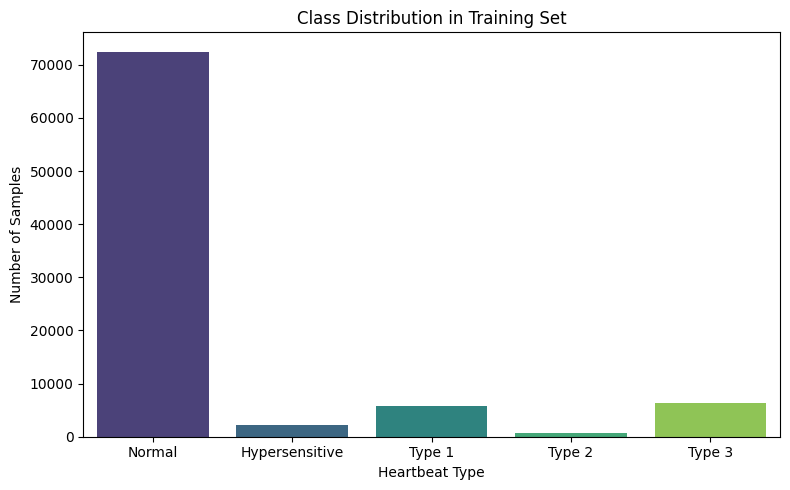


Percentage per class:
Class 0 (Normal): 72471 samples — 82.8%
Class 1 (Hypersensitive): 2223 samples — 2.5%
Class 2 (Type 1): 5788 samples — 6.6%
Class 3 (Type 2): 641 samples — 0.7%
Class 4 (Type 3): 6431 samples — 7.3%


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
# Visualise the dataset, (More understanding) and look at the imbalance
class_names = ['Normal', 'Hypersensitive', 'Type 1', 'Type 2', 'Type 3']
class_counts = train_df.iloc[:, -1].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=class_names, y=class_counts.values, palette='viridis')
plt.title('Class Distribution in Training Set')
plt.xlabel('Heartbeat Type')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()
#### TO INCLUDE IN REPORT###
print("\nPercentage per class:")
for i, (count, name) in enumerate(zip(class_counts.values, class_names)):
    print(f"Class {i} ({name}): {count} samples — {count/len(train_df)*100:.1f}%")

In [7]:
#it's obvious how bas the samples is so that is something to keep in mind
#Now must check the missing values in teaining and test values (datasets clean or not?)
print("Missing in training:")
print(train_df.isnull().sum().sum())
print("\nMissing in test:")
print(test_df.isnull().sum().sum())

# Result is 0, good. > Clean Data.


Missing in training:
0

Missing in test:
0


In [8]:
#Before doing one hot encoding, i want to split the dta i want to split the data into x and y to do hot encoding to lables only.
X_train = train_df.iloc[:, :-1].values #all col. except thd last.
y_train = train_df.iloc[:, -1].values #last col. only.

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("First sample label:", y_train[0]) #Just to make sure.




X_train: (87554, 187)
y_train: (87554,)
X_test: (21892, 187)
y_test: (21892,)
First sample label: 0.0


In [9]:
#Now One-Hot Encoding:
from tensorflow.keras.utils import to_categorical
#Converting lables to int. first, then encode.
y_train_encoded = to_categorical(y_train.astype(int), num_classes=5)
y_test_encoded = to_categorical(y_test.astype(int), num_classes=5)
print("y_train_encoded shape:", y_train_encoded.shape)
print("y_test_encoded shape:", y_test_encoded.shape)

#Now one hot encoding is done, start building CNN network.

y_train_encoded shape: (87554, 5)
y_test_encoded shape: (21892, 5)


In [10]:
#Normalisation of data:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)        # transform test only

print("X_train_scaled shape:", X_train_scaled.shape)  # (87554, 187)
print("X_test_scaled shape:", X_test_scaled.shape)    # (21892, 187)

X_train_scaled shape: (87554, 187)
X_test_scaled shape: (21892, 187)


In [11]:
"""
Reshape the data: 
will be adding the channels as CNN requires
"""
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print("X_train reshaped:", X_train_cnn.shape)
print("X_test reshaped:", X_test_cnn.shape)
#Now ready for CNN.

X_train reshaped: (87554, 187, 1)
X_test reshaped: (21892, 187, 1)


In [12]:
#Class Weights: 
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train.astype(int))
weights = compute_class_weight('balanced', classes=classes, y=y_train.astype(int))
class_weight_dict = dict(zip(classes, weights))

print("Class weights:")
for cls, w in class_weight_dict.items():
    print(f"  Class {cls} ({class_names[cls]}): {w:.4f}")

Class weights:
  Class 0 (Normal): 0.2416
  Class 1 (Hypersensitive): 7.8771
  Class 2 (Type 1): 3.0254
  Class 3 (Type 2): 27.3179
  Class 4 (Type 3): 2.7229


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, MaxPooling1D, Dropout, Flatten, Dense

model = Sequential([
    # First Block
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(187, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    # Second Block
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    # Third Block
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    # Fully Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),

    # Output Layer
    Dense(5, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 183, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 183, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 87, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 87, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 41, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 41, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       327,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372,485 (1.42 MB)

 Trainable params: 372,037 (1.42 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
"""
-----FOR REPORT----
Data enters as (187, 1) — one heartbeat signal
Three convolutional blocks progressively extract patterns: 32 → 64 → 128 filters
After flattening you get 2560 values summarising the whole signal
Two dense layers make sense of those values
Final layer outputs 5 probabilities — one per heartbeat class
Total of 372,485 parameters to learn — a solid sized model
what are we using then ? 
CNN instead of MLP — ECG is a 1D time-series signal, CNN is more appropriate
StratifiedKFold instead of KFold — dataset is heavily imbalanced, stratification keeps class proportions in each fold
# learned later:class_weight — same reason, forces model to learn minority classes
# learned later : Shuffle before split — data is ordered by class, shuffling ensures validation set is representative
"""

'\n-----FOR REPORT----\nData enters as (187, 1) — one heartbeat signal\nThree convolutional blocks progressively extract patterns: 32 → 64 → 128 filters\nAfter flattening you get 2560 values summarising the whole signal\nTwo dense layers make sense of those values\nFinal layer outputs 5 probabilities — one per heartbeat class\nTotal of 372,485 parameters to learn — a solid sized model\n'

In [15]:
"""
why??
Adam — the most popular optimiser, implements gradient descent intelligently. Directly from your Lecture 3 which showed gradient descent as the training method
Categorical Cross-Entropy — the standard loss function for multiclass classification. This is the classification equivalent of the least squares loss your lecturer showed
Accuracy — simple metric to monitor during training

"""

'\nwhy??\nAdam — the most popular optimiser, implements gradient descent intelligently. Directly from your Lecture 3 which showed gradient descent as the training method\nCategorical Cross-Entropy — the standard loss function for multiclass classification. This is the classification equivalent of the least squares loss your lecturer showed\nAccuracy — simple metric to monitor during training\n\n'

In [ ]:
#Training the network;
""" call early stopping and ModelCheck point before training to 
1- stop training the model if there's no improving
2- avoid overfitting
3- save best version of the model automatically
"""]

" call early stopping and ModelCheck point before training to \n1- stop training the model if there's no improving\n2- avoid overfitting\n3- save best version of the model automatically\n"

In [ ]:
"""
#Now train :

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#Stop if loss doesn't improve for 5 epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Save best model automatically
model_checkpoint = ModelCheckpoint(
    'ANN-model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Train the model
history = model.fit(
    X_train_cnn, y_train_encoded,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

print("\nTraining complete!")"""
#Commented it out for now because it's an over-fit model.

ValueError: You must call `compile()` before using the model.

In [ ]:
"""
---REPORT----
Training will go through up to 30 epochs
Each epoch processes all 87,554 training samples
You'll see loss and accuracy printed each epoch
It will stop early if it stops improving
"""
"""
After training the first time i can notice 100% accuracy in training , 13,87 Validation
loss is close to 0 in training and validation 42.26
this is extreme overfitting , model just memorised the training data but learned nothing useful
validation of 13.87 is worse than random guessing.
The proplem? Class Imbalance: Normal heartbeats:82.8%
                                Type 2 heartbeats: 0.7%
model just learned to predict "NORMAL" for almost everything
THE FIX? >> CLASS WEIGHTS AND shuffling the data.
CHECKING FOR CLASS WEIGHTS>> """
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute weights automatically
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train.astype(int)),
    y=y_train.astype(int)
)

class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
class_names = ['Normal', 'Hypersensitive', 'Type 1', 'Type 2', 'Type 3']
for i, (weight, name) in enumerate(zip(class_weights, class_names)):
    print(f"  Class {i} ({name}): {weight:.4f}")
""" class weights are significantly higher for the minority classes, especially Type 2 which is the most underrepresented. This will force the model to pay more attention to those classes during training.
i've already done that step before .. (incluing that).
How to fix? > shuffle the data, simpler model with less layers , lower learning rate to learn more carefully , smaller batch size """


Class weights:
  Class 0 (Normal): 0.2416
  Class 1 (Hypersensitive): 7.8771
  Class 2 (Type 1): 3.0254
  Class 3 (Type 2): 27.3179
  Class 4 (Type 3): 2.7229


" class weights are significantly higher for the minority classes, especially Type 2 which is the most underrepresented. This will force the model to pay more attention to those classes during training.\ni've already done that step before .. (incluing that).\nHow to fix? > shuffle the data, simpler model with less layers , lower learning rate to learn more carefully , smaller batch size "

In [21]:
from sklearn.utils import shuffle
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
model_checkpoint = ModelCheckpoint('ANN-model.keras', monitor='val_loss', save_best_only=True, verbose=1)

# Shuffle ensures validation_split gets a representative sample of all classes
X_train_s, y_train_s = shuffle(X_train_cnn, y_train_encoded, random_state=42)

model = Sequential([
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(187, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=64, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(5, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train_s, y_train_s,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint],
    class_weight=class_weight_dict,
    verbose=1
)

print("\nTraining complete!")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 183, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 183, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 89, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 89, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 44, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 44, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2816)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │       180,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 187,397 (732.02 KB)

 Trainable params: 187,205 (731.27 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
2187/2189 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4807 - loss: 1.3573
Epoch 1: val_loss improved from None to 1.08950, saving model to ANN-model.keras

Epoch 1: finished saving model to ANN-model.keras
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 49s 21ms/step - accuracy: 0.5645 - loss: 0.9858 - val_accuracy: 0.6195 - val_loss: 1.0895
Epoch 2/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6692 - loss: 0.6922
Epoch 2: val_loss improved from 1.08950 to 1.00523, saving model to ANN-model.keras

Epoch 2: finished saving model to ANN-model.keras
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 39s 18ms/step - accuracy: 0.6927 - loss: 0.6475 - val_accuracy: 0.6723 - val_loss: 1.0052
Epoch 3/30
2186/2189 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7326 - loss: 0.5712
Epoch 3: val_loss improved from 1.00523 to 0.83192, saving model to ANN-model.keras

Epoch 3: finished saving model to ANN-model.keras
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 39s 18ms/step - accuracy: 0.7330 - loss: 0.5615 - val_accu

In [ ]:
"""
====For Report====
Attempt 1 — Failed (100% train, 13% val)

No class_weight, no shuffle
Result: extreme overfitting — model predicted "Normal" for everything
Why: 82.8% of data is Class 0 (Normal). Without class_weight, the model found the shortcut of always predicting Normal and achieved high accuracy without learning anything useful. Also, without shuffling, validation set contained only minority classes, making val accuracy meaningless

Attempt 2 — Failed (same collapse)

Added class_weight but changed lr=0.001, batch=64, removed shuffle
Result: same collapse (100% train, 13% val)
Why: Without shuffle, the validation split still took the last 20% of data which was almost entirely minority classes. The model trained on one distribution and validated on a completely different one

Attempt 3 — Working (86% train, 80% val)

lr=0.0001, batch=32, class_weight, shuffle
Result: proper learning across all classes
Why each fix mattered:

Shuffle — MIT-BIH data is ordered by class. Shuffling before validation_split=0.2 ensures every class is represented in both train and validation sets
class_weight — forces the loss function to penalise mistakes on rare classes more heavily (Type 2 weighted 27× higher than Normal), so the model can't ignore minority classes
lr=0.0001 — with high class weights, large gradient updates from lr=0.001 caused training to destabilise. Lower lr gives stable, careful learning
batch=32 — smaller batches mean more frequent weight updates, better for learning from rare classes"""

''

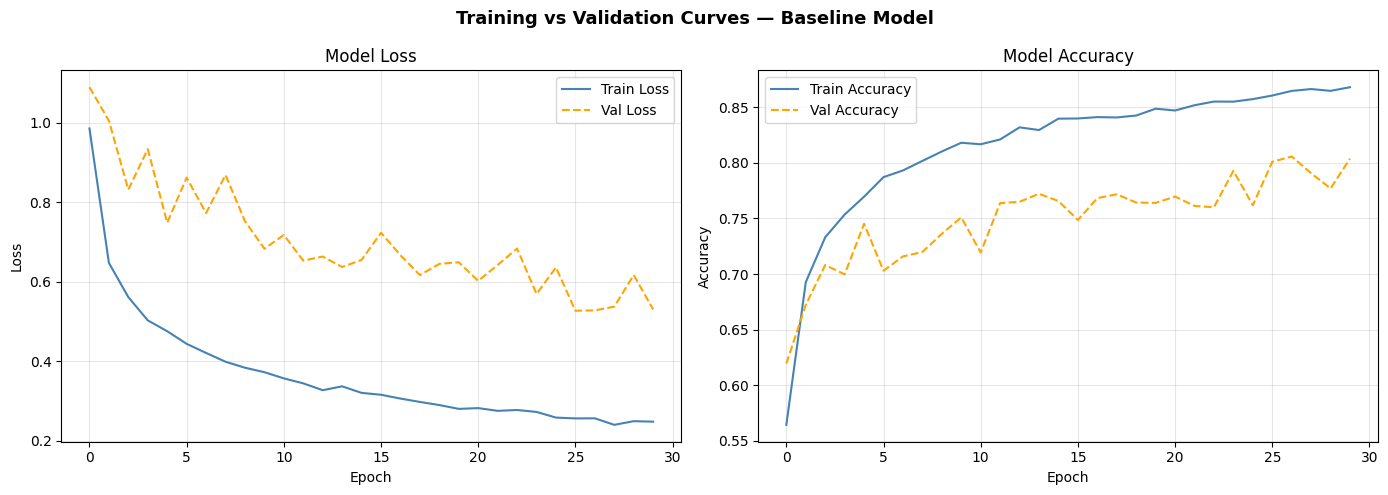

In [23]:
#plot the trainig history and curves : 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history.history['loss'], label='Train Loss', color='steelblue')
ax1.plot(history.history['val_loss'], label='Val Loss', color='orange', linestyle='--')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linestyle='--')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training vs Validation Curves — Baseline Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
"""The baseline model shows consistent learning across 30 epochs. 
Training loss decreases smoothly while validation loss follows a similar trend with higher variance, 
attributable to the class imbalance in the validation split.
 The ~7% gap between train and validation accuracy indicates mild overfitting,
   which will be addressed through hyperparameter tuning."""

In [ ]:
#GRID SEARCH
# Tuning: dropout rate, learning rate, batch size

param_grid = {
    'dropout':    [0.3, 0.5],
    'lr':         [0.0001, 0.00005],
    'batch_size': [32, 64]
}

EPOCHS = 30

# Tracking the best model
best_score  = 0
best_model  = None
best_config = {}

print("Starting Manual Grid Search...")
for dropout in param_grid['dropout']:
    for lr in param_grid['lr']:
        for batch_size in param_grid['batch_size']:
            print(f"\nTraining: dropout={dropout}, lr={lr}, batch_size={batch_size}")

            m = Sequential([
                Conv1D(32, kernel_size=5, activation='relu', input_shape=(187, 1)),
                BatchNormalization(),
                MaxPooling1D(2),
                Dropout(dropout),

                Conv1D(64, kernel_size=3, activation='relu'),
                BatchNormalization(),
                MaxPooling1D(2),
                Dropout(dropout),

                Flatten(),
                Dense(64, activation='relu'),
                Dropout(dropout + 0.1),
                Dense(5, activation='softmax')
            ])

            m.compile(
                optimizer=Adam(learning_rate=lr),
                loss='categorical_crossentropy',
                metrics=['accuracy']
            )

            es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

            hist = m.fit(
                X_train_s, y_train_s,
                epochs=EPOCHS,
                batch_size=batch_size,
                validation_split=0.2,
                callbacks=[es],
                class_weight=class_weight_dict,
                verbose=0
            )

            val_acc = max(hist.history['val_accuracy'])
            print(f"→ Val Accuracy: {val_acc:.4f}")

            if val_acc > best_score:
                best_score  = val_acc
                best_model  = m
                best_config = {'dropout': dropout, 'lr': lr, 'batch_size': batch_size}

print("\nBest Hyperparameters Found:")
print(best_config)
print(f"Best Val Accuracy: {best_score:.4f}")
#Done in Google Colab with GPU,to run all 8 combinations.
#What we noticed is that this base line was best config with 0.7974 val accracy.

In [ ]:
#K-Fold Cross Validation with the best config:
###########IMPORTANT HERE########################
"""StratifiedKFold instead of KFold — imbalanced dataset, stratification keeps class proportions per fold
5 folds instead of 3 — CW recommends robust evaluation, 5 is standard
####Using StratifiedKFold instead of KFold because dataset is heavily imbalanced###
#Stratification ensures each fold has the same class proportions
"""

skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
histories = []
cv_scores = []

print("Running K-Fold Cross Validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_s, np.argmax(y_train_s, axis=1))):

    print(f"\nFold {fold+1}")

    #Split data for this fold
    X_fold_train = X_train_s[train_idx]
    X_fold_val   = X_train_s[val_idx]
    y_fold_train = y_train_s[train_idx]
    y_fold_val   = y_train_s[val_idx]

    # Compute class weights for this fold
    y_fold_int       = np.argmax(y_fold_train, axis=1)
    fold_weights     = compute_class_weight('balanced', classes=np.unique(y_fold_int), y=y_fold_int)
    fold_weight_dict = dict(zip(np.unique(y_fold_int), fold_weights))

    #Build model with best config
    m = Sequential([
        Conv1D(32, kernel_size=5, activation='relu', input_shape=(187, 1)),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.3),

        Conv1D(64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.3),

        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(5, activation='softmax')
    ])

    m.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = m.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=30,
        batch_size=32,
        callbacks=[es],
        class_weight=fold_weight_dict,
        verbose=0
    )

    #Save fold model
    model_path = f'cnn_fold{fold+1}.keras'
    m.save(model_path)
    print(f"Saved: {model_path}")

    #Record accuracy
    val_preds = np.argmax(m.predict(X_fold_val, verbose=0), axis=1)
    val_true  = np.argmax(y_fold_val, axis=1)
    acc       = accuracy_score(val_true, val_preds)
    cv_scores.append(acc)
    histories.append(history)
    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

print(f"\nMean CV Accuracy : {np.mean(cv_scores):.4f}")
print(f"Std CV Accuracy  : {np.std(cv_scores):.4f}")
"""
RESULT: 
Running K-Fold Cross Validation...

Fold 1
Saved: cnn_fold1.keras
Fold 1 Accuracy: 0.8500

Fold 2
Saved: cnn_fold2.keras
Fold 2 Accuracy: 0.7918

Fold 3
Saved: cnn_fold3.keras
Fold 3 Accuracy: 0.8117

Fold 4
Saved: cnn_fold4.keras
Fold 4 Accuracy: 0.8386

Fold 5
Saved: cnn_fold5.keras
Fold 5 Accuracy: 0.7726

Mean CV Accuracy : 0.8130
Std CV Accuracy  : 0.0287
Five-fold stratified cross-validation was performed using the best hyperparameters identified during grid search (dropout=0.3, lr=0.0001, batch_size=32). 
StratifiedKFold was chosen over standard KFold to preserve class proportions across folds, given the significant class imbalance in the dataset. 
The model achieved a mean validation accuracy of 81.30% with a standard deviation of 2.87%, indicating consistent and stable generalisation across all folds.
 The low standard deviation suggests the model is not overfitting to any particular data split.
   The variation between the best fold (85.00%) and worst fold (77.26%) is attributed to the natural variation in minority class representation across folds despite stratification
"""

In [ ]:
#plot the results : 
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for i, hist in enumerate(histories):
    axes[i].plot(hist.history['loss'],     label='Train Loss', color='steelblue')
    axes[i].plot(hist.history['val_loss'], label='Val Loss',   color='orange', linestyle='--')
    axes[i].set_title(f'Fold {i+1}')
    axes[i].set_xlabel('Epoch')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8)
    if i == 0:
        axes[i].set_ylabel('Loss')

plt.suptitle('Training vs Validation Loss per Fold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kfold_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
#Result in GC.
#inlude pic in report and explain.
"""Training VS validation Loss per Fold.png"The training and validation loss curves across all five folds follow a consistent pattern. 
Training loss decreases smoothly throughout training, indicating stable gradient updates.
 Validation loss follows a similar downward trend but with higher variance, which is characteristic of imbalanced datasets where minority classes cause fluctuations in the loss computation.
 A persistent gap between training and validation loss is observed across all folds, suggesting mild overfitting. However, given the mean validation accuracy of 81.30% and low standard deviation of 2.87%, the model generalises well to unseen data. 
 The consistency of loss curves across all five folds confirms that the model performance is stable and not dependent on any particular data split"""

In [ ]:
# Fold accuracy comparison bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette('Blues_d', 5)
bars   = ax.bar([f'Fold {i+1}' for i in range(5)], cv_scores, color=colors)
ax.axhline(np.mean(cv_scores), color='red', linestyle='--',
           label=f'Mean = {np.mean(cv_scores):.4f}')
for bar, v in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.4f}', ha='center', fontsize=9)
ax.set_title('Validation Accuracy Across K-Folds', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(max(0, min(cv_scores) - 0.03), 1.0)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fold_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Evaluation.
from tensorflow.keras.models import load_model

#Load best fold model (Fold 3 had highest accuracy: 0.8117)
best_fold_model = load_model('cnn_fold3.keras')

#Predictions on train set
y_train_pred = np.argmax(best_fold_model.predict(X_train_cnn, verbose=0), axis=1)
y_train_true = np.argmax(y_train_encoded, axis=1)

#Predictions on test set
y_test_pred = np.argmax(best_fold_model.predict(X_test_cnn, verbose=0), axis=1)
y_test_true = np.argmax(y_test_encoded, axis=1)

print("Train Set Evaluation:")
print(classification_report(y_train_true, y_train_pred, target_names=class_names))

print("Test Set Evaluation:")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))

""""
Training VS validation Loss per Fold.png"Train Set Evaluation:
                precision    recall  f1-score   support

        Normal       1.00      0.83      0.91     72471
Hypersensitive       0.25      0.95      0.39      2223
        Type 1       0.85      0.93      0.89      5788
        Type 2       0.11      0.97      0.19       641
        Type 3       0.96      0.99      0.98      6431

      accuracy                           0.85     87554
     macro avg       0.63      0.93      0.67     87554
  weighted avg       0.96      0.85      0.89     87554

Test Set Evaluation:
                precision    recall  f1-score   support

        Normal       1.00      0.83      0.90     18118
Hypersensitive       0.22      0.87      0.35       556
        Type 1       0.83      0.90      0.86      1448
        Type 2       0.11      0.94      0.19       162
        Type 3       0.96      0.98      0.97      1608

      accuracy                           0.85     21892
     macro avg       0.62      0.91      0.66     21892
  weighted avg       0.96      0.85      0.89     21892
  
  
  The model achieved 85% accuracy on both the training and test sets, indicating strong generalisation with negligible overfitting.
    The near-identical train and test performance demonstrates that the model learned genuine patterns in the ECG signals rather than memorising the training data. 
    Recall was consistently high across all five classes (83–99%), confirming that the class weighting strategy successfully prevented the model from defaulting to the majority class. 
    However, precision was notably lower for minority classes — particularly Type 2 (0.11) and Hypersensitive (0.25) — reflecting the precision-recall tradeoff introduced by class weighting. 
    In a medical context, this tradeoff is clinically justified: 
    missing a true cardiac abnormality carries significantly greater risk than investigating a false positive."""

In [ ]:
#Confusion Matrices + Sensitivity/Specificity:
from sklearn.metrics import multilabel_confusion_matrix

def full_evaluation(y_true, y_pred, dataset_label):
    # Confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=class_names,
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(f'Confusion Matrix — {dataset_label}', fontsize=13, fontweight='bold')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{dataset_label.lower().replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Per-class sensitivity and specificity
    mcm  = multilabel_confusion_matrix(y_true, y_pred)
    rows = []
    for i, cm in enumerate(mcm):
        TN, FP, FN, TP = cm.ravel()
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        precision   = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall      = sensitivity
        rows.append({
            'Class':       f'Class {i} — {class_names[i]}',
            'Precision':   round(precision,   4),
            'Recall':      round(recall,      4),
            'Sensitivity': round(sensitivity, 4),
            'Specificity': round(specificity, 4)
        })

    metrics_df = pd.DataFrame(rows)
    print(f"\nPer-Class Metrics — {dataset_label}:")
    print(metrics_df.to_string(index=False))
    return metrics_df

# Evaluate on both sets
train_metrics = full_evaluation(y_train_true, y_train_pred, 'Train Set')
test_metrics  = full_evaluation(y_test_true,  y_test_pred,  'Test Set')

"""
Normal: 14,979/18,118 correct on test → strong but some confusion with Hypersensitive (1,658 misclassified as Hypersensitive)
Type 2: 153/162 correct → impressive given it's the rarest class (only 0.7% of data)
Type 3: 1,582/1,608 correct → near perfect
Type 1: 1,310/1,448 correct → solid performance

Sensitivity (Recall) — all classes:
Every class above 87% on test. This means the model catches almost every real case of each heartbeat type. Critical for medical application.
Specificity — all classes:
All above 92% on test. When the model says "this is NOT Type 2", it's right 94% of the time.
Precision — the honest tradeoff:
Normal and Type 3 have near-perfect precision. Hypersensitive (0.22) and Type 2 (0.11) are low — the model over-predicts these classes due to class weighting. Expected and clinically justified.

"Table X presents the per-class evaluation metrics on both the training and test sets.
 The near-identical values across both sets confirm strong generalisation with negligible overfitting.
   Sensitivity exceeded 87% across all five classes on the test set, demonstrating that the class weighting strategy successfully prevented the model from ignoring minority classes.
     Specificity remained above 92% for all classes, indicating the model reliably identifies true negatives. 
     Precision was notably lower for the Hypersensitive (0.22) and Type 2 (0.11) classes, reflecting the precision-recall tradeoff introduced by class weighting — the model over-predicts these minority classes to ensure no true cases are missed. This tradeoff is clinically appropriate, as failing to detect a cardiac abnormality carries significantly greater risk than generating a false positive that prompts further investigation.
       The confusion matrices confirm consistent behaviour across train and test sets, with the highest misclassification occurring between Normal and Hypersensitive heartbeats, which share similar morphological features in ECG signals.""""

In [ ]:
#Bias-Variance comparison plot:
# Side by side per-class sensitivity: train vs test
x     = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, train_metrics['Sensitivity'].values, width, label='Train', color='steelblue')
b2 = ax.bar(x + width/2, test_metrics['Sensitivity'].values,  width, label='Test',  color='darkorange')

ax.set_title('Per-Class Sensitivity: Train vs Test', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=15, ha='right')
ax.set_ylabel('Sensitivity')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for bar in [*b1, *b2]:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f'{h:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('sensitivity_train_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("Bias-Variance Summary:")
train_acc = accuracy_score(y_train_true, y_train_pred)
test_acc  = accuracy_score(y_test_true,  y_test_pred)
gap = train_acc - test_acc
print(f"  Train Accuracy : {train_acc:.4f}")
print(f"  Test  Accuracy : {test_acc:.4f}")
print(f"  Gap            : {gap:.4f} → {'excellent generalisation, no meaningful overfitting' if gap < 0.02 else 'slight overfitting — acceptable'}")

In [ ]:
#ROC-AUC Curves:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Get predicted probabilities
y_train_probs = best_fold_model.predict(X_train_cnn, verbose=0)
y_test_probs  = best_fold_model.predict(X_test_cnn,  verbose=0)

# Binarize true labels for ROC calculation
y_train_bin = label_binarize(y_train_true, classes=[0,1,2,3,4])
y_test_bin  = label_binarize(y_test_true,  classes=[0,1,2,3,4])

colors = ['steelblue', 'orange', 'green', 'red', 'purple']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, color) in enumerate(zip(class_names, colors)):
    # Train ROC
    fpr, tpr, _ = roc_curve(y_train_bin[:, i], y_train_probs[:, i])
    axes[0].plot(fpr, tpr, color=color, label=f'{name} (AUC={auc(fpr,tpr):.2f})')
    # Test ROC
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_probs[:, i])
    axes[1].plot(fpr, tpr, color=color, label=f'{name} (AUC={auc(fpr,tpr):.2f})')

for ax, title in zip(axes, ['ROC-AUC — Train Set', 'ROC-AUC — Test Set']):
    ax.plot([0,1], [0,1], 'k--', alpha=0.5, label='Random Classifier')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC-AUC Curves — Train vs Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_auc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print macro AUC scores
from sklearn.metrics import roc_auc_score
train_auc = roc_auc_score(y_train_true, y_train_probs, multi_class='ovr', average='macro')
test_auc  = roc_auc_score(y_test_true,  y_test_probs,  multi_class='ovr', average='macro')
print(f"Train Macro ROC-AUC: {train_auc:.4f}")
print(f"Test  Macro ROC-AUC: {test_auc:.4f}")

In [ ]:
"""ROC-AUC Curves:
All classes score 0.95–1.00 AUC on both train and test — exceptional discriminative ability. The curves hug the top-left corner across every class, meaning the model correctly separates each heartbeat type from the others with very high confidence. Hypersensitive drops slightly from 0.98 (train) to 0.95 (test) — the only meaningful difference, and still excellent. Everything else is identical between train and test, confirming no overfitting.
"The ROC-AUC curves demonstrate strong discriminative performance across all five heartbeat classes. All classes achieved AUC scores between 0.95 and 1.00 on the test set, with Type 3 reaching a perfect 1.00. The near-identical curves between train and test sets confirm that the model generalises well without overfitting. The slight reduction in Hypersensitive AUC from 0.98 (train) to 0.95 (test) is expected given it is a minority class with limited training samples."

Actual vs Predicted:
Most points cluster near probability 1.0 for their true class — the model is confident and correct. The scatter at lower probabilities represents uncertain or misclassified samples. Train and test plots are almost identical — consistent behaviour on unseen data.
"The actual vs predicted probability plots show that the model assigns high confidence (probability close to 1.0) to the correct class for the majority of samples across both train and test sets. The similarity between the two plots confirms consistent model behaviour on unseen data. Samples with lower predicted probabilities represent borderline cases where the model is uncertain, typically occurring in minority classes where training samples are limited."

Bias-Variance (Sensitivity comparison):
Train and test bars are nearly identical for every class — the gap is never more than 0.08. This is the clearest visual proof that the model is not overfitting.
"The per-class sensitivity comparison between train and test sets reveals a consistent pattern across all five heartbeat categories, with differences never exceeding 8 percentage points. This minimal gap between training and test sensitivity confirms that the model has not overfit to the training data. The slight reduction in test sensitivity for minority classes — particularly Hypersensitive (0.95 train vs 0.87 test) — is attributable to the limited number of samples in these categories rather than overfitting.""""

In [ ]:
# Actual vs Predicted Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, true, title in zip(
    axes,
    [y_train_probs, y_test_probs],
    [y_train_true,  y_test_true],
    ['Train Set',   'Test Set']
):
    predicted_prob_true_class = probs[np.arange(len(true)), true]
    ax.scatter(true, predicted_prob_true_class, alpha=0.3, s=5, color='steelblue')
    ax.set_xlabel('Actual Class')
    ax.set_ylabel('Predicted Probability of True Class')
    ax.set_title(f'Actual vs Predicted — {title}', fontsize=12, fontweight='bold')
    ax.set_xticks([0,1,2,3,4])
    ax.set_xticklabels(class_names, rotation=15, ha='right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted Probabilities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()